In [20]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [21]:
#set plot formatting to seaborn's default
sns.set() 

In [22]:
%matplotlib inline

# Loading the cleaned Spotify dataset

In [23]:
df = pd.read_csv('..\Data\spotify_songs_cleaned2.csv')
df.head().T

,0,1,2,3,4
track_name,Dance Monkey,ROXANNE,Blinding Lights,Circles,Tusa
track_artist,Tones and I,Arizona Zervas,The Weeknd,Post Malone,KAROL G
track_popularity,100,99,98,98,98
track_album_name,Dance Monkey (Stripped Back) / Dance Monkey,ROXANNE,Blinding Lights,Hollywood's Bleeding,Tusa
track_album_release_date,2019-10-17,2019-10-10,2019-11-29,2019-09-06,2019-11-07
danceability,0.824,0.621,0.513,0.695,0.803
energy,0.588,0.601,0.796,0.762,0.715
key,6,6,1,0,2
loudness,-6.4,-5.616,-4.075,-3.497,-3.28
mode,0,0,1,1,1


In [24]:
df.shape

(24531, 26)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24531 entries, 0 to 24530
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_name                24531 non-null  object 
 1   track_artist              24531 non-null  object 
 2   track_popularity          24531 non-null  int64  
 3   track_album_name          24531 non-null  object 
 4   track_album_release_date  24531 non-null  object 
 5   danceability              24531 non-null  float64
 6   energy                    24531 non-null  float64
 7   key                       24531 non-null  int64  
 8   loudness                  24531 non-null  float64
 9   mode                      24531 non-null  int64  
 10  speechiness               24531 non-null  float64
 11  acousticness              24531 non-null  float64
 12  instrumentalness          24531 non-null  float64
 13  liveness                  24531 non-null  float64
 14  valenc

# Create dummy variables for categorical variables

In [26]:
# print(df.select_dtypes(include=['object']).columns)

##### These 4 columns are objects, but only key_name will be used for this analysis. Proceed with one-hot encoding for this and create 11 new columns.

In [27]:
# drop_first=True removes the first alphabetical category as a reference
# df = pd.get_dummies(df, columns=['key_name'], prefix='key', drop_first=True)
# df.head()

In [28]:
# Create dummies for 'top_genre' and concatenate
genre_dummies = pd.get_dummies(df['top_genre'], prefix='genre', drop_first=True, dtype=int)
df = pd.concat([df, genre_dummies], axis=1)

# Create dummies for 'top_subgenre' and concatenate
subgenre_dummies = pd.get_dummies(df['top_subgenre'], prefix='subgenre', drop_first=True, dtype=int)
df = pd.concat([df, subgenre_dummies], axis=1)

# View the first few rows of the updated dataframe
df.head()

,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,danceability,energy,key,loudness,mode,...,subgenre_new jack swing,subgenre_permanent wave,subgenre_pop edm,subgenre_post-teen pop,subgenre_progressive electro house,subgenre_reggaeton,subgenre_southern hip hop,subgenre_trap,subgenre_tropical,subgenre_urban contemporary
0,Dance Monkey,Tones and I,100,Dance Monkey (Stripped Back) / Dance Monkey,2019-10-17,0.824,0.588,6,-6.400,0,...,0,0,0,0,0,0,0,0,0,0
1,ROXANNE,Arizona Zervas,99,ROXANNE,2019-10-10,0.621,0.601,6,-5.616,0,...,0,0,0,0,0,0,0,0,0,0
2,Blinding Lights,The Weeknd,98,Blinding Lights,2019-11-29,0.513,0.796,1,-4.075,1,...,0,0,0,0,0,0,0,0,0,0
3,Circles,Post Malone,98,Hollywood's Bleeding,2019-09-06,0.695,0.762,0,-3.497,1,...,0,0,0,0,0,0,0,0,0,0
4,Tusa,KAROL G,98,Tusa,2019-11-07,0.803,0.715,2,-3.280,1,...,0,0,0,0,0,0,0,0,0,0


# Update: Remove key variables
### After examining feature importance for RandomForest model, I see that these variables are contributing very little so the above has been commented out

# Drop unneeded features

In [29]:
# Days since the oldest song in the dataset
df['days_since_release'] = (pd.to_datetime('today') - pd.to_datetime(df['track_album_release_date'])).dt.days

In [30]:
df = df.drop(columns=['track_name', 'track_artist', 'track_album_name', 
                      'duration_ms', 'duration_min', 
                      'track_album_release_date', 'release_year', 'release_month', 'release_day',
                     'key', 'key_name', 'top_genre', 'top_subgenre'
                     ]
            )

# Drop 0 Popularity Tracks

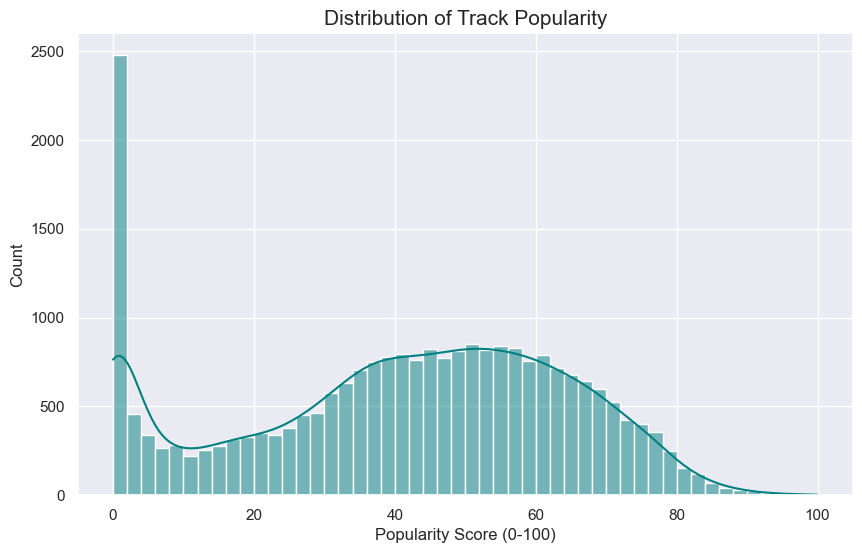

In [31]:
#Plot distribution of popularity
plt.figure(figsize=(10, 6))
sns.histplot(df['track_popularity'], bins=50, kde=True, color='teal')

# Add labels and title
plt.title('Distribution of Track Popularity', fontsize=15)
plt.xlabel('Popularity Score (0-100)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

In [32]:
#After testing models in part 4, I believe these tracks may be contributing a lot of noise so I will remove them
before_len = len(df)
df = df[df['track_popularity']>0]
after_len = len(df)
print("Dropped ", before_len - after_len, "tracks")

Dropped  2080 tracks


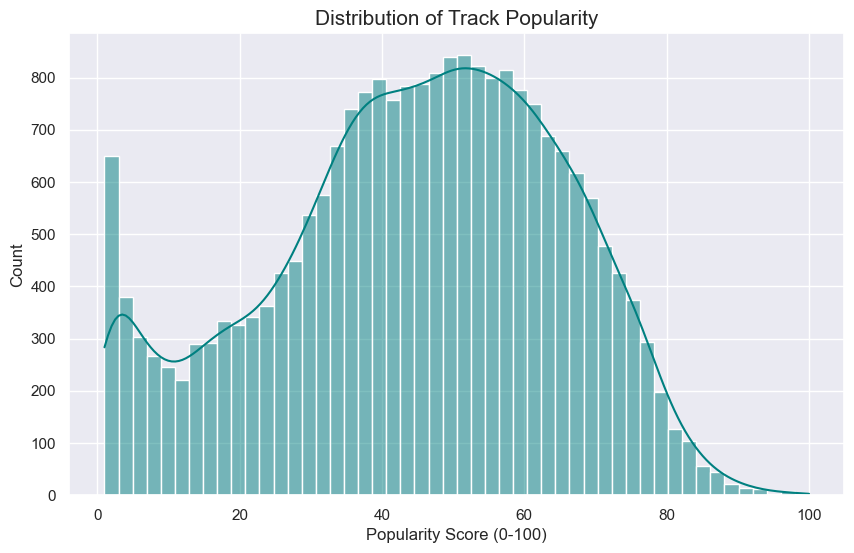

In [33]:
#Plot distribution of popularity to confirm they were dropped
plt.figure(figsize=(10, 6))
sns.histplot(df['track_popularity'], bins=50, kde=True, color='teal')

# Add labels and title
plt.title('Distribution of Track Popularity', fontsize=15)
plt.xlabel('Popularity Score (0-100)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

# Train Test Split

In [34]:
## Define Features (X) and Target (y)
from sklearn.model_selection import train_test_split

X = df.drop(columns=['track_popularity'])
y = df['track_popularity']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Identify numerical columns to scale
# Exclude the boolean 'key' columns, mode, and the target
cols_to_scale = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
    'duration_sec', 'days_since_release', 'track_occurences'
]

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Export Dataset

In [37]:
# save the data to a new csv file
filepath = '..\Data\spotify_songs_cleaned3.csv'
df.to_csv(filepath, index=False)

# Export Pickle

In [38]:
#this will be used in modeling next
import joblib

# Save as a dictionary or individual files
data_split = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}

joblib.dump(data_split, '..\Data\spotify_modeling_data.pkl')

['..\\Data\\spotify_modeling_data.pkl']

# Summary
-One hot encode the categorical field 'key_name'
<br>-Drop unneeded features - these were helpful for EDA but are no longer needed
<br>-Identify the features to scale. Note that not all machine learning alogrithms require scaling but I will prepare the dataset so I can easily proceed with multiple alogrithms. 
<br>-Split data into train and test sets
<br>-Fit the scaler on the training data and transform the test data to prevent data leakage
